In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                                                                              ║
# ║          🔵  MACHINE LEARNING PARA DATA ANALYSTS  ·  2026                   ║
# ║                                                                              ║
# ║          Módulo 05 — CLUSTERING: JERARQUICO Y K-MEANS                       ║
# ║                                                                              ║
# ║          Autor   : Borja Mora Méndez                                         ║
# ║          Stack   : Python · Scikit-learn · Scipy · Matplotlib · Seaborn      ║
# ║          Nivel   : Analyst → ML-Ready                                        ║
# ║          Uso     : Manual de referencia permanente                           ║
# ║                                                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# MAPA DE APRENDIZAJE
# ───────────────────
#   Estadística descriptiva
#       ↓
#   Normalización / escalado de datos          ← PREREQUISITO CLAVE
#       ↓
#   Medidas de distancia (Euclidea · Manhattan)
#       ↓
#   ► CLUSTERING JERÁRQUICO (linkage · dendrogramas)
#       ↓
#   ► CLUSTERING NO JERÁRQUICO — K-Means
#       ↓
#   Evaluación: Elbow · Silhouette
#       ↓
#   DBSCAN (siguiente módulo)
#       ↓
#   Integración en Power BI / Reporting


---
## 📦 1 · Setup y librerías


In [10]:
# ── LIBRERÍAS ─────────────────────────────────────────────────────────────────
import numpy as np                          # Álgebra vectorial y operaciones matemáticas
import pandas as pd                         # Manipulación de DataFrames
import matplotlib.pyplot as plt             # Gráficos base
import matplotlib.patches as mpatches       # Leyendas personalizadas
import seaborn as sns                       # Visualización estadística
from scipy.cluster.hierarchy import (       # Clustering jerárquico
    linkage, dendrogram, fcluster
)
from scipy.spatial.distance import (        # Métricas de distancia
    pdist, squareform, euclidean, cityblock
)
from sklearn.preprocessing import (         # Normalización / escalado
    StandardScaler, MinMaxScaler
)
from sklearn.cluster import (               # Algoritmos de clustering
    KMeans, AgglomerativeClustering
)
from sklearn.metrics import (               # Métricas de evaluación
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)
from sklearn.datasets import make_blobs     # Datos sintéticos para demos
import warnings
warnings.filterwarnings("ignore")

# ── PALETA DE MARCA ────────────────────────────────────────────────────────────
PURPLE      = "#7a7bff"    # Color principal
INK         = "#111111"    # Texto principal
MUTED       = "#888888"    # Texto secundario / ejes
GRAY        = "#e5e5e5"    # Bordes / fondos neutros
GREEN       = "#3c8a37"    # Métricas positivas
RED         = "#a3223e"    # Métricas negativas / alertas
PURPLE_LITE = "#ededff"    # Fondo badges morados

# Paleta multi-cluster (4 clusters max en demos estándar)
CLUSTER_COLORS = ["#7a7bff", "#111111", "#a3223e", "#3c8a37"]

# ── ESTILO MATPLOTLIB ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"        : 130,
    "figure.facecolor"  : "#ffffff",
    "axes.facecolor"    : "#ffffff",
    "axes.edgecolor"    : GRAY,
    "axes.linewidth"    : 0.7,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.color"        : "#f0f0f0",
    "grid.linewidth"    : 0.5,
    "font.family"       : "DejaVu Sans",
    "font.size"         : 11,
    "xtick.color"       : MUTED,
    "ytick.color"       : MUTED,
    "text.color"        : INK,
})

print("✅  Setup completado — Paleta de marca y estilo matplotlib aplicados")


✅  Setup completado — Paleta de marca y estilo matplotlib aplicados


---
## 🧠 2 · ¿Qué es el Clustering?

### Nivel 1 — El problema del mundo real

Imagina que eres Data Analyst en un banco con **500.000 clientes**.  
No tienes ninguna etiqueta que diga "cliente premium", "cliente en riesgo" o "cliente inactivo".  
Solo tienes datos de comportamiento: frecuencia de compra, saldo medio, número de productos, antigüedad.

**¿Cómo agruparías clientes parecidos sin que nadie te haya dado esas categorías?**

Eso es exactamente el Clustering.

---

### Definición profesional

> **Clustering** es el conjunto de técnicas de Machine Learning No Supervisado que agrupan  
> observaciones en función de su **similitud interna** — sin ninguna etiqueta previa.

El algoritmo no sabe qué grupos existen.  
**Los descubre** por sí mismo, encontrando estructura en los datos.

---

### ¿Cuándo necesita una empresa Clustering?

| Situación | Ejemplo real | Sin clustering | Con clustering |
|---|---|---|---|
| Segmentación de clientes | Banco / eCommerce | Todos reciben el mismo email | Campañas distintas por perfil |
| Detección de anomalías | Fraude / calidad | Revisar todos los registros | Solo revisar los "raros" |
| Pricing dinámico | Retail / SaaS | Precio único para todos | Precio adaptado al segmento |
| Análisis de producto | SaaS / App | Reportes generales | Grupos de uso diferenciado |
| RRHH | Multinacional | Plan de retención genérico | Plan por grupo de riesgo |

---

### ¿Cuándo NO usar Clustering?

- Cuando ya tienes etiquetas → usa **clasificación supervisada**
- Cuando buscas predecir un número → usa **regresión**
- Cuando el dataset tiene menos de ~100 filas → analiza manualmente
- Cuando no entiendes los datos → primero EDA, luego cluster


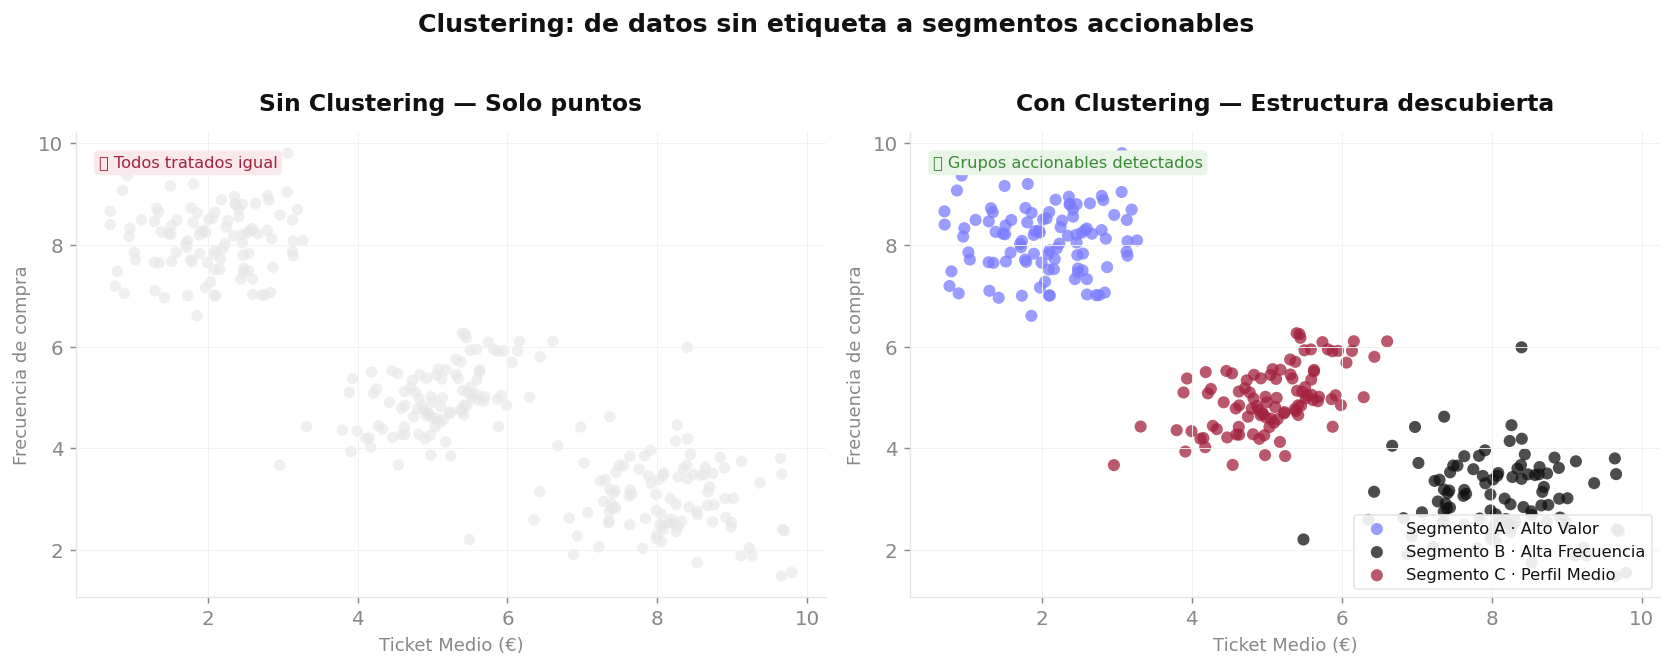

→ Decisión empresarial: cada segmento recibirá una campaña de marketing diferente


In [11]:
# ── VISUALIZACIÓN: ¿Por qué agrupar datos? ────────────────────────────────────
# Generamos un dataset sintético de clientes con dos características

np.random.seed(42)
n = 300

# Simulamos 3 segmentos de clientes
segmento_A = np.random.multivariate_normal([2, 8], [[0.5, 0.1],[0.1, 0.5]], n//3)    # Alto valor, baja frecuencia
segmento_B = np.random.multivariate_normal([8, 3], [[0.6, 0.0],[0.0, 0.6]], n//3)    # Baja valor, alta frecuencia
segmento_C = np.random.multivariate_normal([5, 5], [[0.4, 0.2],[0.2, 0.4]], n//3)    # Perfil medio

X_demo = np.vstack([segmento_A, segmento_B, segmento_C])
true_labels = np.array([0]*100 + [1]*100 + [2]*100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: sin clusters (como ve la empresa sin ML)
axes[0].scatter(X_demo[:, 0], X_demo[:, 1], color=GRAY, alpha=0.6, s=40, edgecolors="none")
axes[0].set_title("Sin Clustering — Solo puntos", fontsize=13, fontweight="bold", color=INK, pad=12)
axes[0].set_xlabel("Ticket Medio (€)", color=MUTED, fontsize=10)
axes[0].set_ylabel("Frecuencia de compra", color=MUTED, fontsize=10)
axes[0].text(0.03, 0.95, "❌ Todos tratados igual", transform=axes[0].transAxes,
             fontsize=9, color=RED, va="top",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="#f9e8ec", edgecolor="none"))

# Panel derecho: con clusters descubiertos
for i, (color, label) in enumerate(zip(CLUSTER_COLORS[:3], ["Segmento A · Alto Valor", "Segmento B · Alta Frecuencia", "Segmento C · Perfil Medio"])):
    mask = true_labels == i
    axes[1].scatter(X_demo[mask, 0], X_demo[mask, 1],
                    color=color, alpha=0.75, s=45, edgecolors="none", label=label)

axes[1].set_title("Con Clustering — Estructura descubierta", fontsize=13, fontweight="bold", color=INK, pad=12)
axes[1].set_xlabel("Ticket Medio (€)", color=MUTED, fontsize=10)
axes[1].set_ylabel("Frecuencia de compra", color=MUTED, fontsize=10)
axes[1].legend(loc="lower right", fontsize=9, framealpha=0.9, edgecolor=GRAY)
axes[1].text(0.03, 0.95, "✅ Grupos accionables detectados", transform=axes[1].transAxes,
             fontsize=9, color=GREEN, va="top",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="#e8f5e7", edgecolor="none"))

plt.suptitle("Clustering: de datos sin etiqueta a segmentos accionables", 
             fontsize=14, fontweight="bold", color=INK, y=1.02)
plt.tight_layout()
plt.savefig("01_clustering_intro.png", dpi=130, bbox_inches="tight")
plt.show()
print("→ Decisión empresarial: cada segmento recibirá una campaña de marketing diferente")


---
## 📍 3 · Centroides — El "centro de gravedad" de un grupo

Un **centroide** es el punto medio de todos los puntos que pertenecen a un cluster.  
Es el "representante matemático" del grupo.

**Analogía:** si tienes 10 clientes en Madrid, 8 en Alcobendas y 2 en Getafe,  
el centroide sería la dirección "media" que mejor representa a todos.

**Matemáticamente:**

$$\bar{x}_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i$$

Donde $C_k$ es el conjunto de puntos del cluster $k$.  
El centroide es la **media de cada variable** para todos los puntos del grupo.

> En clustering, los algoritmos buscan clusters donde los puntos estén  
> **lo más cerca posible de su centroide** y **lo más lejos posible** de los centroides de otros clusters.


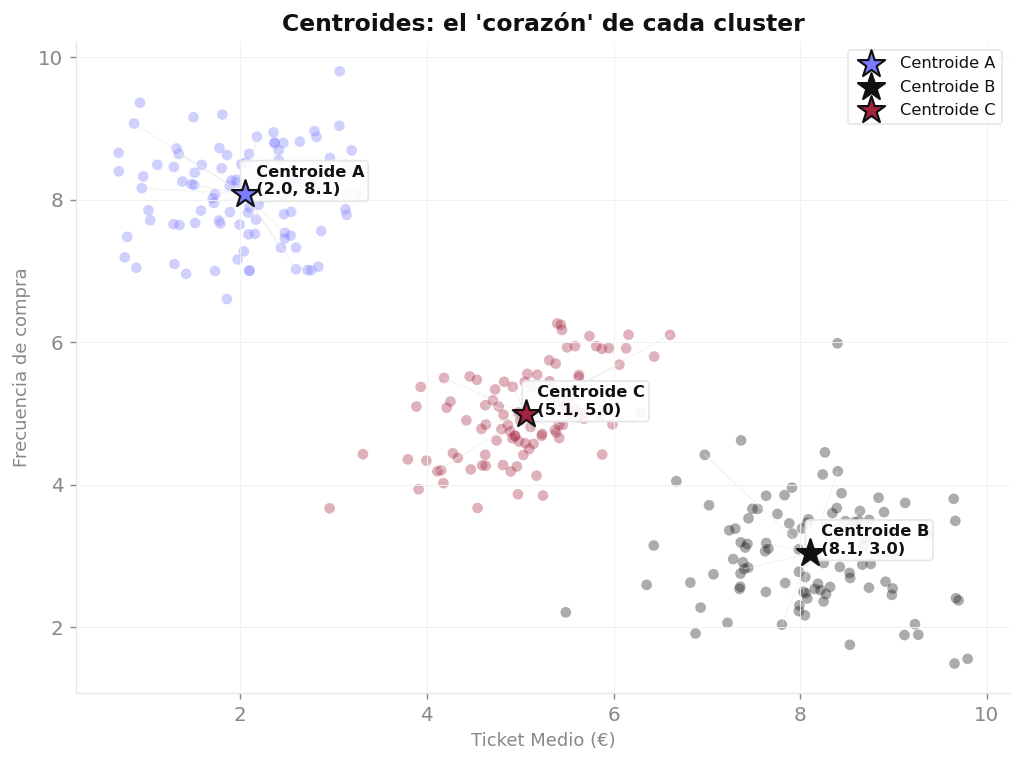

TABLA DE CENTROIDES (lo que vería el analista):
─────────────────────────────────────────────
            Ticket_Medio  Frec_Compra
Segmento A          2.05         8.08
Segmento B          8.10         3.03
Segmento C          5.06         4.98

→ El centroide describe PERFECTAMENTE el perfil medio de cada segmento.


In [13]:
# ── VISUALIZACIÓN DE CENTROIDES ────────────────────────────────────────────────
# Usamos los datos de clientes del ejemplo anterior

# Calculamos centroides manualmente
centroides = np.array([
    X_demo[true_labels == i].mean(axis=0) for i in range(3)
])

fig, ax = plt.subplots(figsize=(8, 6))

# Puntos de cada cluster
for i, (color, label) in enumerate(zip(CLUSTER_COLORS[:3], ["Segmento A", "Segmento B", "Segmento C"])):
    mask = true_labels == i
    ax.scatter(X_demo[mask, 0], X_demo[mask, 1],
               color=color, alpha=0.35, s=35, edgecolors="none")

# Centroides encima
for i, (color, label) in enumerate(zip(CLUSTER_COLORS[:3], ["A", "B", "C"])):
    cx, cy = centroides[i]
    ax.scatter(cx, cy, color=color, s=250, marker="*",
               edgecolors=INK, linewidths=1.2, zorder=5, label=f"Centroide {label}")
    ax.annotate(f"  Centroide {label}\n  ({cx:.1f}, {cy:.1f})",
                xy=(cx, cy), fontsize=9, color=INK, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor=GRAY, alpha=0.9))

# Líneas desde centroide a algunos puntos de muestra
for cluster_idx in range(3):
    cluster_pts = X_demo[true_labels == cluster_idx]
    c = centroides[cluster_idx]
    for pt in cluster_pts[::8]:  # Cada 8 puntos para no saturar
        ax.plot([c[0], pt[0]], [c[1], pt[1]],
                color=GRAY, linewidth=0.6, alpha=0.5, zorder=1)

ax.set_title("Centroides: el 'corazón' de cada cluster", fontsize=13, fontweight="bold", color=INK)
ax.set_xlabel("Ticket Medio (€)", color=MUTED, fontsize=10)
ax.set_ylabel("Frecuencia de compra", color=MUTED, fontsize=10)
ax.legend(fontsize=9, framealpha=0.9, edgecolor=GRAY)
plt.tight_layout()
plt.savefig("02_centroides.png", dpi=130, bbox_inches="tight")
plt.show()

# Tabla de centroides como la vería un analista
print("TABLA DE CENTROIDES (lo que vería el analista):")
print("─" * 45)
df_centroides = pd.DataFrame(centroides, 
                              columns=["Ticket_Medio", "Frec_Compra"],
                              index=["Segmento A", "Segmento B", "Segmento C"])
df_centroides["Ticket_Medio"] = df_centroides["Ticket_Medio"].round(2)
df_centroides["Frec_Compra"]  = df_centroides["Frec_Compra"].round(2)
print(df_centroides.to_string())
print("\n→ El centroide describe PERFECTAMENTE el perfil medio de cada segmento.")


---
## 📐 4 · Cómo medir similitud — Distancias

Para que un algoritmo de clustering pueda agrupar puntos,  
necesita saber **qué tan "parecidos" o "lejanos" son dos puntos**.

La herramienta para eso es la **distancia matemática**.

---

### 4.1 · Distancia Euclidea (la más común)

Es la línea recta entre dos puntos. La misma que usarías con una regla.

$$d_{Euclidea}(A, B) = \sqrt{\sum_{i=1}^{n}(a_i - b_i)^2}$$

**Cuándo usarla:**
- Variables continuas con escala similar
- Cuando la "dirección" importa (no solo la magnitud)
- K-Means por defecto usa esta distancia

---

### 4.2 · Distancia de Manhattan (distancia ciudad)

Suma de las diferencias absolutas en cada dimensión.  
**Analogía:** cómo se mueve un taxi en una ciudad en cuadrícula (Manhattan, NY).

$$d_{Manhattan}(A, B) = \sum_{i=1}^{n}|a_i - b_i|$$

**Cuándo usarla:**
- Cuando hay valores atípicos fuertes (es más robusta)
- Datos de alta dimensionalidad
- Variables que miden magnitudes independientes


In [ ]:
# ── DEMO MANUAL: Cálculo paso a paso de distancias ───────────────────────────

# Dos clientes del banco
cliente_A = np.array([5_000, 12])   # Saldo medio 5.000€, 12 transacciones/mes
cliente_B = np.array([8_000, 4])    # Saldo medio 8.000€,  4 transacciones/mes

print("=" * 55)
print("CÁLCULO DE DISTANCIAS — CLIENTE A vs CLIENTE B")
print("=" * 55)
print(f"
Cliente A: Saldo={cliente_A[0]:,}€  |  Transacciones={cliente_A[1]}/mes")
print(f"Cliente B: Saldo={cliente_B[0]:,}€  |  Transacciones={cliente_B[1]}/mes")

# ── Euclidea ──────────────────────────────────────────────────
diff        = cliente_A - cliente_B
diff_sq     = diff ** 2
suma_sq     = diff_sq.sum()
d_euclidea  = np.sqrt(suma_sq)

print("
── DISTANCIA EUCLIDEA ──────────────────────────────────")
print(f"  Diferencia dim 1 (Saldo)         : {cliente_A[0]} - {cliente_B[0]} = {diff[0]:,}")
print(f"  Diferencia dim 2 (Transacciones) : {cliente_A[1]} - {cliente_B[1]} = {diff[1]}")
print(f"  Cuadrados                        : {diff_sq[0]:,} + {diff_sq[1]} = {suma_sq:,}")
print(f"  Raíz cuadrada                    : √{suma_sq:,} = {d_euclidea:.2f}")
print(f"
  ✅ d_Euclidea(A, B) = {d_euclidea:.2f}")

# ── Manhattan ─────────────────────────────────────────────────
abs_diff    = np.abs(diff)
d_manhattan = abs_diff.sum()

print("
── DISTANCIA DE MANHATTAN ──────────────────────────────")
print(f"  |Saldo A - Saldo B|                : |{diff[0]:,}| = {abs_diff[0]:,}")
print(f"  |Transacciones A - Transacciones B|: |{diff[1]}|  = {abs_diff[1]}")
print(f"  Suma                               : {abs_diff[0]:,} + {abs_diff[1]} = {d_manhattan:,}")
print(f"
  ✅ d_Manhattan(A, B) = {d_manhattan:,.0f}")

# ── Verificación con scipy ─────────────────────────────────────
assert abs(euclidean(cliente_A, cliente_B) - d_euclidea) < 0.001, "Error Euclidea"
assert abs(cityblock(cliente_A, cliente_B) - d_manhattan) < 0.001, "Error Manhattan"
print("
  ✔ Verificado con scipy.spatial.distance")


In [ ]:
# ── VISUALIZACIÓN: Euclidea vs Manhattan ──────────────────────────────────────

A = np.array([1, 1])
B = np.array([5, 4])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, title, mode in zip(axes, 
                            ["Distancia Euclidea
(línea recta)", 
                             "Distancia Manhattan
(movimiento en cuadrícula)"],
                            ["euclidea", "manhattan"]):

    # Puntos
    ax.scatter(*A, color=PURPLE, s=150, zorder=5)
    ax.scatter(*B, color=RED,    s=150, zorder=5)
    ax.text(A[0]-0.25, A[1]+0.2, "A (1,1)", fontsize=10, color=PURPLE, fontweight="bold")
    ax.text(B[0]+0.1,  B[1]+0.2, "B (5,4)", fontsize=10, color=RED,    fontweight="bold")

    if mode == "euclidea":
        d = np.sqrt((B[0]-A[0])**2 + (B[1]-A[1])**2)
        ax.plot([A[0], B[0]], [A[1], B[1]], color=PURPLE, linewidth=2.5, linestyle="-")
        ax.annotate("", xy=B, xytext=A,
                    arrowprops=dict(arrowstyle="-|>", color=PURPLE, lw=2))
        ax.text(2.8, 2.0, f"d = √[(5-1)² + (4-1)²]
  = √(16+9) = √25
  = {d:.2f}",
                fontsize=10, color=PURPLE,
                bbox=dict(boxstyle="round,pad=0.4", facecolor=PURPLE_LITE, edgecolor="none"))
    else:
        d = abs(B[0]-A[0]) + abs(B[1]-A[1])
        # Camino horizontal + vertical
        ax.plot([A[0], B[0]], [A[1], A[1]], color=PURPLE, linewidth=2.5)
        ax.plot([B[0], B[0]], [A[1], B[1]], color=RED,    linewidth=2.5)
        ax.annotate("Horizontal: |5-1|=4", xy=((A[0]+B[0])/2, A[1]-0.3),
                    ha="center", fontsize=9, color=PURPLE)
        ax.annotate("Vertical: |4-1|=3",  xy=(B[0]+0.2, (A[1]+B[1])/2),
                    ha="left",  fontsize=9, color=RED)
        ax.text(1.5, 3.5, f"d = |5-1| + |4-1|
  = 4 + 3 = {d:.0f}",
                fontsize=10, color=INK,
                bbox=dict(boxstyle="round,pad=0.4", facecolor=PURPLE_LITE, edgecolor="none"))

    ax.set_xlim(-0.2, 6.5)
    ax.set_ylim(-0.2, 5.5)
    ax.set_title(title, fontsize=12, fontweight="bold", color=INK)
    ax.set_xlabel("Variable 1", color=MUTED, fontsize=10)
    ax.set_ylabel("Variable 2", color=MUTED, fontsize=10)
    ax.grid(True, alpha=0.4)
    ax.set_xticks(range(7))
    ax.set_yticks(range(6))

plt.suptitle("Euclidea vs Manhattan: misma lógica, distinto camino", 
             fontsize=13, fontweight="bold", color=INK)
plt.tight_layout()
plt.savefig("03_distancias.png", dpi=130, bbox_inches="tight")
plt.show()


---
## ⚠️ 5 · El problema de las magnitudes (error que comete el 90% de los juniors)

Imagina que quieres agrupar clientes usando:
- **Saldo medio** → valores entre 0 y 50.000 €
- **Número de productos** → valores entre 1 y 10

Si calculas la distancia euclidea **sin normalizar**, la diferencia de saldo (50.000) 
**aplasta completamente** a la diferencia de productos (9).

El algoritmo actuará como si el número de productos **no existiera**.

Esto es el **problema de diferencia de magnitudes** y es la causa número 1  
de clusters sin sentido en proyectos reales.

> **Regla de oro:** Antes de cualquier clustering, **normaliza siempre** tus variables.


In [ ]:
# ── DEMO DEL PROBLEMA DE MAGNITUDES ──────────────────────────────────────────
np.random.seed(7)
n_clientes = 200

# Dataset con variables de magnitudes muy distintas
df_clientes = pd.DataFrame({
    "saldo_medio_eur"    : np.concatenate([
        np.random.normal(500,   150, n_clientes//2),   # Grupo bajo valor
        np.random.normal(15000, 2000, n_clientes//2)   # Grupo alto valor
    ]),
    "num_productos"      : np.concatenate([
        np.random.normal(2, 0.8, n_clientes//2),
        np.random.normal(8, 0.8, n_clientes//2)
    ])
})
df_clientes["num_productos"] = df_clientes["num_productos"].clip(1, 10).round(1)
df_clientes["saldo_medio_eur"] = df_clientes["saldo_medio_eur"].clip(0)

print("📊 ESTADÍSTICAS DESCRIPTIVAS:")
print("─" * 45)
print(df_clientes.describe().round(1))
print(f"
⚠️  Diferencia máxima de SALDO     : {df_clientes['saldo_medio_eur'].max() - df_clientes['saldo_medio_eur'].min():,.0f}€")
print(f"⚠️  Diferencia máxima de PRODUCTOS : {df_clientes['num_productos'].max()  - df_clientes['num_productos'].min():.1f}")
print(f"
→ La magnitud del saldo es {(df_clientes['saldo_medio_eur'].max()/df_clientes['num_productos'].max()):.0f}x mayor que la de productos")
print("→ Sin normalizar, el algoritmo IGNORARÁ los productos al calcular distancias")

# K-Means SIN normalizar
km_raw = KMeans(n_clusters=2, random_state=42, n_init=10)
df_clientes["cluster_raw"] = km_raw.fit_predict(df_clientes)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_clientes["saldo_medio_eur"], df_clientes["num_productos"],
                c=[CLUSTER_COLORS[c] for c in df_clientes["cluster_raw"]],
                alpha=0.6, s=45, edgecolors="none")
axes[0].set_title("K-Means SIN normalizar
(distancia dominada por el saldo)", 
                   fontsize=11, fontweight="bold", color=INK)
axes[0].set_xlabel("Saldo medio (€)", color=MUTED)
axes[0].set_ylabel("Nº Productos", color=MUTED)
axes[0].text(0.05, 0.95, "❌ Ignora Nº Productos", transform=axes[0].transAxes,
             fontsize=9, color=RED, va="top",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="#f9e8ec", edgecolor="none"))

# K-Means CON normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clientes[["saldo_medio_eur", "num_productos"]])
km_scaled = KMeans(n_clusters=2, random_state=42, n_init=10)
df_clientes["cluster_scaled"] = km_scaled.fit_predict(X_scaled)

axes[1].scatter(df_clientes["saldo_medio_eur"], df_clientes["num_productos"],
                c=[CLUSTER_COLORS[c] for c in df_clientes["cluster_scaled"]],
                alpha=0.6, s=45, edgecolors="none")
axes[1].set_title("K-Means CON normalización
(ambas variables contribuyen igual)", 
                   fontsize=11, fontweight="bold", color=INK)
axes[1].set_xlabel("Saldo medio (€)", color=MUTED)
axes[1].set_ylabel("Nº Productos", color=MUTED)
axes[1].text(0.05, 0.95, "✅ Considera ambas variables", transform=axes[1].transAxes,
             fontsize=9, color=GREEN, va="top",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="#e8f5e7", edgecolor="none"))

plt.suptitle("El impacto de normalizar antes del Clustering", 
             fontsize=13, fontweight="bold", color=INK)
plt.tight_layout()
plt.savefig("04_magnitudes.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 🔧 6 · Normalización de datos

Dos técnicas principales para poner todas las variables en la misma escala:

---

### StandardScaler (Z-score Normalization)
$$z = \frac{x - \mu}{\sigma}$$

- Centra en 0, desviación estándar = 1
- **Cuándo:** cuando los datos siguen distribución aproximadamente normal
- **Ideal para:** K-Means, clustering jerárquico, PCA

---

### MinMaxScaler (Normalización min-max)
$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

- Escala al rango [0, 1]
- **Cuándo:** cuando necesitas un rango fijo
- **Cuidado:** muy sensible a outliers


In [ ]:
# ── NORMALIZACIÓN: StandardScaler vs MinMaxScaler ────────────────────────────
# Ejemplo con variables reales de clientes bancarios

np.random.seed(1)
df_norm = pd.DataFrame({
    "saldo_eur"       : np.random.exponential(scale=5000, size=500),
    "num_productos"   : np.random.randint(1, 11, size=500).astype(float),
    "meses_antiguedad": np.random.normal(60, 24, size=500).clip(1, 240),
    "transacciones_mes": np.random.poisson(15, size=500).astype(float)
})

# Aplicar ambos scalers
ss  = StandardScaler()
mms = MinMaxScaler()

X_ss  = pd.DataFrame(ss.fit_transform(df_norm),  columns=df_norm.columns, index=df_norm.index)
X_mms = pd.DataFrame(mms.fit_transform(df_norm), columns=df_norm.columns, index=df_norm.index)

# Comparativa estadística
print("📊 ESTADÍSTICAS ANTES / DESPUÉS DE NORMALIZAR")
print("=" * 60)
resumen = pd.DataFrame({
    "Original_Media"  : df_norm.mean().round(1),
    "Original_Std"    : df_norm.std().round(1),
    "Original_Min"    : df_norm.min().round(1),
    "Original_Max"    : df_norm.max().round(1),
    "ZScore_Media"    : X_ss.mean().round(2),
    "ZScore_Std"      : X_ss.std().round(2),
    "MinMax_Min"      : X_mms.min().round(2),
    "MinMax_Max"      : X_mms.max().round(2),
})
print(resumen.to_string())

# Visualización: distribuciones antes y después
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
col_names = df_norm.columns.tolist()
labels    = ["Original", "StandardScaler (Z-score)", "MinMaxScaler [0,1]"]
dfs       = [df_norm, X_ss, X_mms]

for row_idx, (df_plot, lbl) in enumerate(zip(dfs, labels)):
    for col_idx, col in enumerate(col_names):
        ax = axes[row_idx][col_idx]
        ax.hist(df_plot[col], bins=25, color=PURPLE if row_idx == 1 else (GRAY if row_idx == 0 else "#7a7bff55"),
                edgecolor="none", alpha=0.85)
        ax.set_title(f"{col}
{lbl}", fontsize=8, fontweight="bold", color=INK)
        ax.set_xlabel("")
        ax.tick_params(labelsize=7)
        # Stats mini
        mu  = df_plot[col].mean()
        std = df_plot[col].std()
        ax.text(0.97, 0.94, f"μ={mu:.2f}
σ={std:.2f}", transform=ax.transAxes,
                fontsize=7, ha="right", va="top", color=MUTED)

plt.suptitle("Distribuciones: Original → StandardScaler → MinMaxScaler", 
             fontsize=13, fontweight="bold", color=INK, y=1.01)
plt.tight_layout()
plt.savefig("05_normalizacion.png", dpi=130, bbox_inches="tight")
plt.show()

print("
✅ Después del StandardScaler: todas las variables tienen μ≈0 y σ≈1")
print("✅ Después del MinMaxScaler:   todas las variables están en [0, 1]")
print("
⚠️  REGLA PROFESIONAL: Para clustering, StandardScaler es la opción por defecto")
print("   Solo usa MinMaxScaler si tienes razones específicas (ej: datos sin outliers)")


---
## 🌳 7 · Clustering Jerárquico

### ¿Qué problema resuelve?

K-Means requiere que decidas de antemano cuántos clusters quieres.  
El **clustering jerárquico** no necesita ese parámetro.  
Construye un **árbol de similitudes** (dendrograma) que te permite elegir  
el número de grupos **después** de ver la estructura de los datos.

---

### ¿Por qué nació?

En biología y taxonomía (años 50-60) los científicos necesitaban  
clasificar especies sin saber de antemano cuántas familias existían.  
El clustering jerárquico surgió como solución natural.

---

### Dos enfoques

| Enfoque | Nombre | Descripción |
|---|---|---|
| **Bottom-up** | Aglomerativo | Empieza con N clusters (uno por punto). Fusiona los más cercanos hasta quedar 1 |
| **Top-down** | Divisivo | Empieza con 1 cluster. Divide hasta que cada punto es su propio cluster |

> En la práctica profesional se usa casi siempre el **Aglomerativo**.


In [ ]:
# ── VISUALIZACIÓN: Procedimiento Aglomerativo paso a paso ───────────────────
# 6 clientes simplificados para ver el proceso manualmente

np.random.seed(5)
X_hier = np.array([
    [1.0, 1.5],   # C1
    [1.5, 2.0],   # C2 — muy cerca de C1
    [3.0, 1.0],   # C3
    [3.5, 1.5],   # C4 — muy cerca de C3
    [6.0, 5.0],   # C5
    [6.5, 5.5],   # C6 — muy cerca de C5
])
nombres = ["C1", "C2", "C3", "C4", "C5", "C6"]

# Matriz de distancias euclideas
dist_matrix = squareform(pdist(X_hier, metric="euclidean"))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Puntos originales (Paso 0: N clusters = 1 por punto)
ax = axes[0]
ax.scatter(X_hier[:, 0], X_hier[:, 1], color=PURPLE, s=120, zorder=5, edgecolors=INK, linewidths=0.8)
for i, name in enumerate(nombres):
    ax.annotate(f" {name}", xy=X_hier[i], fontsize=11, fontweight="bold", color=INK)
ax.set_title("Paso 0: Cada punto
es su propio cluster", fontsize=11, fontweight="bold", color=INK)
ax.set_xlim(-0.2, 8); ax.set_ylim(-0.2, 7)

# Panel 2: Primera fusión (clusters más cercanos se unen)
ax = axes[1]
ax.scatter(X_hier[:, 0], X_hier[:, 1], color=GRAY, s=100, zorder=4, edgecolors=INK, linewidths=0.6)
# Marcar los pares más cercanos
for pair, color in [([0,1], PURPLE), ([2,3], RED), ([4,5], GREEN)]:
    pts = X_hier[pair]
    ax.plot(pts[:, 0], pts[:, 1], color=color, linewidth=2, alpha=0.7)
    centroid = pts.mean(axis=0)
    ax.scatter(*centroid, marker="*", color=color, s=200, zorder=6, edgecolors=INK, linewidths=0.8)
for i, name in enumerate(nombres):
    ax.annotate(f" {name}", xy=X_hier[i], fontsize=11, fontweight="bold", color=INK)
ax.set_title("Paso 1: Los pares más cercanos
se fusionan", fontsize=11, fontweight="bold", color=INK)
ax.set_xlim(-0.2, 8); ax.set_ylim(-0.2, 7)

# Panel 3: Dendrograma
ax = axes[2]
Z = linkage(X_hier, method="ward")
dendrogram(Z, labels=nombres, ax=ax, 
           color_threshold=3,
           above_threshold_color=MUTED,
           leaf_font_size=11)
ax.set_title("Dendrograma final:
árbol de fusiones", fontsize=11, fontweight="bold", color=INK)
ax.set_xlabel("Puntos / Clusters", color=MUTED, fontsize=9)
ax.set_ylabel("Distancia de fusión (Ward)", color=MUTED, fontsize=9)
# Línea de corte
ax.axhline(y=4.0, color=PURPLE, linewidth=1.5, linestyle="--", alpha=0.8)
ax.text(4.2, 4.1, "Corte → 3 clusters", color=PURPLE, fontsize=9, fontweight="bold")

plt.suptitle("Procedimiento del Clustering Jerárquico Aglomerativo", 
             fontsize=13, fontweight="bold", color=INK)
plt.tight_layout()
plt.savefig("06_jerarquico_pasos.png", dpi=130, bbox_inches="tight")
plt.show()

print("→ El dendrograma nos dice cuántos clusters elegir: buscamos el 'salto más largo'")
print("→ En este ejemplo, cortar a altura ≈4 da 3 grupos naturales: {C1,C2}, {C3,C4}, {C5,C6}")


---
## 🔗 8 · Distancia entre Clusters — Métodos de Enlace (Linkage)

Cuando fusionamos dos puntos en un cluster, ¿cómo medimos la distancia  
de ese **nuevo cluster** respecto a los demás?

Aquí es donde entran los **métodos de enlace**:

| Método | Cómo mide | Cuándo usar | Cuidado con |
|---|---|---|---|
| **Single** (min) | Distancia mínima entre puntos de ambos clusters | Detectar clusters elongados | Efecto cadena (chain effect) |
| **Complete** (max) | Distancia máxima entre puntos de ambos clusters | Clusters compactos y esféricos | Sensible a outliers |
| **Average** | Promedio de todas las distancias cruzadas | Balance entre single y complete | Más costoso computacionalmente |
| **Ward** | Minimiza la varianza interna total al fusionar | **Más usado en la práctica** | Solo funciona con distancia Euclidea |

> **Regla profesional:** Empieza siempre con **Ward** como primera opción.  
> Cambia a Complete si los clusters son muy irregulares.


In [ ]:
# ── COMPARATIVA DE MÉTODOS DE ENLACE ─────────────────────────────────────────
# Dataset con estructura no trivial para ver diferencias

np.random.seed(42)
X_link, _ = make_blobs(n_samples=150, centers=3, cluster_std=1.2, random_state=42)

metodos   = ["single", "complete", "average", "ward"]
titulos   = ["Single (mínima)", "Complete (máxima)", "Average (media)", "Ward (varianza) ⭐"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, (metodo, titulo) in enumerate(zip(metodos, titulos)):
    # Fila superior: dendrograma
    Z = linkage(X_link, method=metodo)
    ax_dend = axes[0][col]
    dendrogram(Z, ax=ax_dend, no_labels=True, color_threshold=None,
               above_threshold_color=PURPLE if metodo == "ward" else MUTED,
               leaf_font_size=1)
    ax_dend.set_title(titulo, fontsize=10, fontweight="bold", 
                       color=PURPLE if metodo == "ward" else INK)
    ax_dend.set_ylabel("Distancia" if col == 0 else "", color=MUTED, fontsize=9)
    ax_dend.tick_params(axis="y", labelsize=8, colors=MUTED)

    # Fila inferior: scatter con clusters resultantes
    ax_scat = axes[1][col]
    model   = AgglomerativeClustering(n_clusters=3, linkage=metodo)
    labels  = model.fit_predict(X_link)
    for k in range(3):
        mask = labels == k
        ax_scat.scatter(X_link[mask, 0], X_link[mask, 1],
                        color=CLUSTER_COLORS[k], alpha=0.65, s=35, edgecolors="none")
    ax_scat.set_title(f"Clusters con {metodo}", fontsize=9, color=MUTED)
    ax_scat.set_xlabel("Var 1", color=MUTED, fontsize=8)
    if col == 0:
        ax_scat.set_ylabel("Var 2", color=MUTED, fontsize=9)
    
    # Score Silhouette como indicador de calidad
    sil = silhouette_score(X_link, labels)
    ax_scat.text(0.05, 0.93, f"Silhouette: {sil:.2f}", transform=ax_scat.transAxes,
                 fontsize=8, color=PURPLE if metodo == "ward" else MUTED, va="top",
                 bbox=dict(boxstyle="round,pad=0.25", facecolor=PURPLE_LITE if metodo == "ward" else "#f8f8f8",
                           edgecolor="none"))

plt.suptitle("Comparativa de Métodos de Enlace (Linkage) — Dendrogramas + Clusters resultantes",
             fontsize=13, fontweight="bold", color=INK)
plt.tight_layout()
plt.savefig("07_linkage_methods.png", dpi=130, bbox_inches="tight")
plt.show()

print("📌 CONCLUSIÓN: Ward produce clusters más compactos y equilibrados.")
print("   Silhouette más alto → clusters de mayor calidad.")


---
## 🏦 9 · Caso Real — Segmentación de Clientes Bancarios con Clustering Jerárquico


In [ ]:
# ── DATASET REALISTA: Clientes de un banco ───────────────────────────────────
np.random.seed(2026)
n = 250

perfiles = {
    # Perfil               saldo_k  productos  antig_meses  trans_mes  num_filas
    "Premium"       : dict(saldo=25, prods=7.5, antig=84, trans=25,  n=50),
    "Activo_Medio"  : dict(saldo=8,  prods=3.5, antig=36, trans=18,  n=80),
    "Digital_Joven" : dict(saldo=3,  prods=2.0, antig=12, trans=35,  n=70),
    "Inactivo"      : dict(saldo=1,  prods=1.2, antig=60, trans=2,   n=50),
}

dfs = []
for nombre, p in perfiles.items():
    d = pd.DataFrame({
        "saldo_medio_keur"     : np.random.normal(p["saldo"], p["saldo"]*0.25, p["n"]).clip(0),
        "num_productos"        : np.random.normal(p["prods"], 0.8, p["n"]).clip(1, 10).round(0),
        "antiguedad_meses"     : np.random.normal(p["antig"], p["antig"]*0.2, p["n"]).clip(1, 240).round(0),
        "transacciones_mes"    : np.random.normal(p["trans"], p["trans"]*0.3, p["n"]).clip(0).round(0),
        "perfil_real"          : nombre
    })
    dfs.append(d)

df_bank = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=42)
df_bank.reset_index(drop=True, inplace=True)

features = ["saldo_medio_keur", "num_productos", "antiguedad_meses", "transacciones_mes"]
print("📊 Dataset Bancario — Primeras filas:")
print(df_bank[features].describe().round(1))
print(f"
Total clientes: {len(df_bank)}")


In [ ]:
# ── PASO 1: Normalización ─────────────────────────────────────────────────────
scaler_bank = StandardScaler()
X_bank      = scaler_bank.fit_transform(df_bank[features])
print("✅ Normalización aplicada — todas las variables en escala Z-score")
print(f"   Media tras escalado: {X_bank.mean(axis=0).round(3)}")
print(f"   Std  tras escalado: {X_bank.std(axis=0).round(3)}")

# ── PASO 2: Dendrograma para elegir nº de clusters ────────────────────────────
Z_bank = linkage(X_bank, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dn = dendrogram(Z_bank, ax=ax, no_labels=True,
                color_threshold=7,
                above_threshold_color=MUTED)

# Marcamos línea de corte óptima
ax.axhline(y=7, color=PURPLE, linewidth=2, linestyle="--", alpha=0.9)
ax.text(245, 7.3, "← Corte óptimo
   k = 4 clusters", color=PURPLE, fontsize=10, fontweight="bold")

ax.set_title("Dendrograma — Clientes Bancarios (Ward Linkage)", 
             fontsize=13, fontweight="bold", color=INK)
ax.set_xlabel("Clientes (250)", color=MUTED, fontsize=10)
ax.set_ylabel("Distancia de fusión (Ward)", color=MUTED, fontsize=10)
ax.tick_params(colors=MUTED)
plt.tight_layout()
plt.savefig("08_bank_dendrogram.png", dpi=130, bbox_inches="tight")
plt.show()
print("
→ El 'salto más largo' en el dendrograma ocurre antes de la altura 7")
print("→ Eso nos indica que k=4 es el número natural de grupos en estos datos")


In [ ]:
# ── PASO 3: Asignar clusters y analizar perfiles ──────────────────────────────
modelo_hier = AgglomerativeClustering(n_clusters=4, linkage="ward")
df_bank["cluster"] = modelo_hier.fit_predict(X_bank)

# Perfil de cada cluster
perfil_clusters = df_bank.groupby("cluster")[features].mean().round(2)
perfil_clusters.columns = ["Saldo (k€)", "Nº Productos", "Antigüedad (m)", "Trans./mes"]

# Añadir tamaño
perfil_clusters["N_clientes"] = df_bank.groupby("cluster").size()

print("📊 PERFIL DE CADA CLUSTER:")
print("=" * 65)
print(perfil_clusters.to_string())

# ── Etiquetas de negocio basadas en los perfiles ──────────────
etiquetas = {
    perfil_clusters["Saldo (k€)"].idxmax()     : "🥇 Cliente Premium",
    perfil_clusters["Trans./mes"].idxmax()      : "📱 Digital Activo",
    perfil_clusters["N_clientes"].idxmax()      : "⚖️  Perfil Medio",
}
# El restante es Inactivo
for k in range(4):
    if k not in etiquetas:
        etiquetas[k] = "💤 Cliente Inactivo"

df_bank["segmento"] = df_bank["cluster"].map(etiquetas)

# ── Visualización final ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Saldo vs Transacciones coloreado por segmento
seg_colors = {
    "🥇 Cliente Premium" : PURPLE,
    "📱 Digital Activo"  : GREEN,
    "⚖️  Perfil Medio"   : INK,
    "💤 Cliente Inactivo": GRAY,
}

ax = axes[0]
for seg, color in seg_colors.items():
    mask = df_bank["segmento"] == seg
    ax.scatter(df_bank.loc[mask, "saldo_medio_keur"],
               df_bank.loc[mask, "transacciones_mes"],
               color=color, alpha=0.65, s=45, label=seg, edgecolors="none")
ax.set_title("Segmentación bancaria
(Clustering Jerárquico Ward, k=4)", 
             fontsize=11, fontweight="bold", color=INK)
ax.set_xlabel("Saldo Medio (k€)", color=MUTED)
ax.set_ylabel("Transacciones / mes", color=MUTED)
ax.legend(fontsize=9, framealpha=0.9, edgecolor=GRAY)

# Barras de tamaño por segmento
ax2 = axes[1]
counts = df_bank["segmento"].value_counts()
bar_colors = [seg_colors.get(s, GRAY) for s in counts.index]
bars = ax2.barh(counts.index, counts.values, color=bar_colors, alpha=0.85, height=0.55)
ax2.set_title("Distribución de clientes
por segmento", fontsize=11, fontweight="bold", color=INK)
ax2.set_xlabel("Nº clientes", color=MUTED)
for bar, val in zip(bars, counts.values):
    ax2.text(val + 1, bar.get_y() + bar.get_height()/2,
             f"{val} ({val/len(df_bank)*100:.0f}%)", va="center", fontsize=9, color=INK)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig("09_bank_segments.png", dpi=130, bbox_inches="tight")
plt.show()

print("
💼 DECISIÓN DE NEGOCIO:")
print("   🥇 Premium   → Programa VIP + Gestor personal")
print("   📱 Digital   → App first: ofertas push + productos digitales")
print("   ⚖️  Medio     → Campaña cross-sell para subir a Premium")
print("   💤 Inactivo  → Campaña reactivación o análisis de churn")


---
## ⚙️ 10 · Clustering No Jerárquico — Algoritmo K-Means

### ¿Qué problema resuelve?

El clustering jerárquico es excelente, pero **no escala**.  
Para 500.000 clientes, calcular todas las distancias entre todos los puntos  
requiere enormes recursos computacionales.

**K-Means** resuelve exactamente eso: es **rápido, escalable y eficiente**,  
y es el algoritmo de clustering más usado en la industria.

---

### ¿Por qué se llama K-Means?

- **K** → número de clusters que defines tú
- **Means** → medias (centroides) que el algoritmo actualiza iterativamente

---

### El algoritmo — 5 pasos

```
1. INICIALIZACIÓN   → Coloca K centroides de forma aleatoria (o inteligente)
2. ASIGNACIÓN       → Asigna cada punto al centroide más cercano
3. ACTUALIZACIÓN    → Recalcula cada centroide como la media de sus puntos
4. REPETICIÓN       → Repite pasos 2 y 3 hasta convergencia
5. RESULTADO        → Clusters estables donde ningún punto cambiaría de grupo
```

> **Convergencia** significa que los centroides ya no se mueven  
> (o se mueven menos de un umbral mínimo).


In [ ]:
# ── K-MEANS PASO A PASO VISUALIZADO ──────────────────────────────────────────
# Implementación manual de K-Means para ver cada iteración

np.random.seed(42)
X_km, _ = make_blobs(n_samples=120, centers=3, cluster_std=1.0,
                     center_box=(0, 10), random_state=42)

def kmeans_manual(X, k=3, max_iter=5, seed=0):
    """K-Means manual para visualizar el proceso iteración a iteración."""
    rng = np.random.default_rng(seed)
    # Inicialización: elegir k puntos al azar
    idx        = rng.choice(len(X), k, replace=False)
    centroids  = X[idx].copy()
    historia   = [("Inicialización", centroids.copy(), np.zeros(len(X), dtype=int))]
    
    for it in range(max_iter):
        # Asignación
        dists  = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = dists.argmin(axis=1)
        # Actualización
        new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        historia.append((f"Iteración {it+1}", new_centroids.copy(), labels.copy()))
        if np.allclose(centroids, new_centroids, atol=1e-6):
            break
        centroids = new_centroids
    return historia

historia = kmeans_manual(X_km, k=3, max_iter=6)

# Mostramos: inicialización + iter 1 + iter 2 + final
pasos_a_mostrar = [0, 1, 2, -1]
titulos_pasos   = ["Paso 1: Inicialización
(centroides aleatorios)",
                   "Paso 2: Asignación
(cada punto → centroide más cercano)",
                   "Paso 3: Actualización
(centroides se mueven a la media)",
                   "Resultado final
(centroides estables)"]

fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))

for ax, paso_idx, titulo in zip(axes, pasos_a_mostrar, titulos_pasos):
    titulo_paso, centroids_plot, labels_plot = historia[paso_idx]
    
    if paso_idx == 0:  # Inicialización: todos los puntos en gris
        ax.scatter(X_km[:, 0], X_km[:, 1], color=GRAY, s=35, alpha=0.7, edgecolors="none")
    else:
        for k_idx in range(3):
            mask = labels_plot == k_idx
            ax.scatter(X_km[mask, 0], X_km[mask, 1],
                       color=CLUSTER_COLORS[k_idx], s=35, alpha=0.65, edgecolors="none")
    
    # Centroides: estrella grande
    for k_idx, c in enumerate(centroids_plot):
        ax.scatter(c[0], c[1], marker="*", s=350, color=CLUSTER_COLORS[k_idx],
                   edgecolors=INK, linewidths=1.2, zorder=10)
    
    ax.set_title(titulo, fontsize=10, fontweight="bold", color=INK)
    ax.set_xlim(X_km[:, 0].min()-1, X_km[:, 0].max()+1)
    ax.set_ylim(X_km[:, 1].min()-1, X_km[:, 1].max()+1)
    ax.set_xlabel("Variable 1", color=MUTED, fontsize=8)
    ax.set_ylabel("Variable 2" if paso_idx == 0 else "", color=MUTED, fontsize=8)
    
    # Añadir coordenadas de centroides
    for k_idx, c in enumerate(centroids_plot):
        ax.text(c[0]+0.2, c[1]+0.2, f"  ({c[0]:.1f},{c[1]:.1f})",
                fontsize=7.5, color=INK, fontweight="bold")

plt.suptitle("K-Means: del caos a los clusters en 4 pasos", 
             fontsize=13, fontweight="bold", color=INK)
plt.tight_layout()
plt.savefig("10_kmeans_pasos.png", dpi=130, bbox_inches="tight")
plt.show()
print("→ Los ⭐ son los centroides — se mueven en cada iteración hasta estabilizarse")


---
## 🎯 11 · Inicialización Inteligente — K-Means++

El K-Means clásico elige los centroides iniciales **aleatoriamente**.  
Esto puede provocar que el algoritmo converja en una solución **subóptima**.

**K-Means++** (2007, Arthur & Vassilvitskii) resuelve esto con una inicialización inteligente:

1. Elige el primer centroide aleatoriamente
2. Para cada punto restante, calcula la distancia al centroide más cercano ya elegido
3. Elige el siguiente centroide con **probabilidad proporcional a esa distancia²**
4. Los puntos más alejados de los centroides existentes tienen más probabilidad de ser elegidos
5. Repite hasta tener K centroides

**Resultado:** centroides iniciales bien distribuidos → convergencia más rápida y consistente.

> `KMeans(init='k-means++')` en scikit-learn usa K-Means++ por defecto desde 2010.  
> Nunca lo cambies a `init='random'` sin una razón muy específica.


In [ ]:
# ── RANDOM vs K-MEANS++: Impacto de la inicialización ────────────────────────
np.random.seed(99)
X_init, _ = make_blobs(n_samples=200, centers=4, cluster_std=0.9, random_state=99)

n_runs = 20   # Ejecutar 20 veces para ver variabilidad

inertias_random  = []
inertias_kpp     = []
silhouettes_random = []
silhouettes_kpp    = []

for seed in range(n_runs):
    km_random = KMeans(n_clusters=4, init="random",    n_init=1, random_state=seed)
    km_kpp    = KMeans(n_clusters=4, init="k-means++", n_init=1, random_state=seed)
    
    km_random.fit(X_init)
    km_kpp.fit(X_init)
    
    inertias_random.append(km_random.inertia_)
    inertias_kpp.append(km_kpp.inertia_)
    silhouettes_random.append(silhouette_score(X_init, km_random.labels_))
    silhouettes_kpp.append(silhouette_score(X_init, km_kpp.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Inertia comparison
ax = axes[0]
ax.plot(range(n_runs), inertias_random, color=GRAY, linewidth=1.5,
        marker="o", markersize=5, label="Random init", alpha=0.8)
ax.plot(range(n_runs), inertias_kpp,    color=PURPLE, linewidth=2,
        marker="o", markersize=5, label="K-Means++ ⭐", alpha=0.9)
ax.axhline(np.mean(inertias_random), color=GRAY, linewidth=1, linestyle="--", alpha=0.7)
ax.axhline(np.mean(inertias_kpp),    color=PURPLE, linewidth=1.5, linestyle="--", alpha=0.7)
ax.set_title("Inercia por ejecución
(más bajo = mejor)", fontsize=11, fontweight="bold", color=INK)
ax.set_xlabel("Nº ejecución", color=MUTED)
ax.set_ylabel("Inercia (WCSS)", color=MUTED)
ax.legend(fontsize=10)

# Silhouette comparison
ax2 = axes[1]
ax2.plot(range(n_runs), silhouettes_random, color=GRAY, linewidth=1.5,
         marker="s", markersize=5, label="Random init", alpha=0.8)
ax2.plot(range(n_runs), silhouettes_kpp,    color=PURPLE, linewidth=2,
         marker="s", markersize=5, label="K-Means++ ⭐", alpha=0.9)
ax2.set_title("Silhouette Score por ejecución
(más alto = mejor)", fontsize=11, fontweight="bold", color=INK)
ax2.set_xlabel("Nº ejecución", color=MUTED)
ax2.set_ylabel("Silhouette Score", color=MUTED)
ax2.legend(fontsize=10)

plt.suptitle(f"Random init vs K-Means++ ({n_runs} ejecuciones independientes)",
             fontsize=13, fontweight="bold", color=INK)
plt.tight_layout()
plt.savefig("11_init_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"
📊 RESUMEN DE {n_runs} EJECUCIONES:")
print(f"{'Métrica':<25} {'Random init':>15} {'K-Means++':>15}")
print("─" * 58)
print(f"{'Inercia media':<25} {np.mean(inertias_random):>15,.1f} {np.mean(inertias_kpp):>15,.1f}")
print(f"{'Inercia std':<25} {np.std(inertias_random):>15,.1f} {np.std(inertias_kpp):>15,.1f}")
print(f"{'Silhouette medio':<25} {np.mean(silhouettes_random):>15.3f} {np.mean(silhouettes_kpp):>15.3f}")
print(f"
✅ K-Means++ es más consistente y produce mejores resultados en todas las ejecuciones")


---
## 📏 12 · ¿Cuántos clusters elegir? — Elbow Method + Silhouette Score

La pregunta más frecuente en proyectos reales: **¿cuánto vale K?**

Dos técnicas complementarias:

### Elbow Method (Método del Codo)
- Ejecuta K-Means para K = 1, 2, ..., n
- Mide la **inercia** (WCSS: Within-Cluster Sum of Squares) para cada K
- Busca el punto donde la inercia deja de caer bruscamente → el "codo"

### Silhouette Score
- Mide qué tan bien separados están los clusters
- Rango: de -1 (mal) a +1 (perfecto)
- Elige K donde el Silhouette sea máximo

> **Regla profesional:** Usa ambas técnicas juntas. Si no coinciden, prioriza  
> el que tenga más sentido de **negocio**.


In [ ]:
# ── ELBOW + SILHOUETTE: Encontrando el K óptimo ──────────────────────────────
# Usamos el dataset bancario normalizado

K_range    = range(2, 11)
inertias   = []
silhouettes = []
dbi_scores  = []   # Davies-Bouldin: más bajo = mejor

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=15, random_state=42)
    km.fit(X_bank)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_bank, km.labels_))
    dbi_scores.append(davies_bouldin_score(X_bank, km.labels_))

# ── Gráfica ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Elbow
ax = axes[0]
ax.plot(K_range, inertias, color=PURPLE, linewidth=2.5, marker="o",
        markersize=7, markerfacecolor="white", markeredgecolor=PURPLE, markeredgewidth=2)
ax.axvline(x=4, color=RED, linewidth=1.5, linestyle="--", alpha=0.8)
ax.text(4.15, max(inertias)*0.85, "K=4
← codo", color=RED, fontsize=9, fontweight="bold")
ax.set_title("Elbow Method — Inercia (WCSS)", fontsize=11, fontweight="bold", color=INK)
ax.set_xlabel("Número de clusters K", color=MUTED)
ax.set_ylabel("Inercia (WCSS)", color=MUTED)
ax.set_xticks(K_range)

# Silhouette
ax2 = axes[1]
bar_cols = [PURPLE if k == K_range[np.argmax(silhouettes)] else GRAY for k in K_range]
bars = ax2.bar(K_range, silhouettes, color=bar_cols, alpha=0.85, width=0.6)
ax2.set_title("Silhouette Score — Calidad clusters", fontsize=11, fontweight="bold", color=INK)
ax2.set_xlabel("Número de clusters K", color=MUTED)
ax2.set_ylabel("Silhouette Score", color=MUTED)
ax2.set_xticks(K_range)
for bar, val in zip(bars, silhouettes):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.2f}",
             ha="center", fontsize=8, color=INK if val == max(silhouettes) else MUTED,
             fontweight="bold" if val == max(silhouettes) else "normal")

# Davies-Bouldin
ax3 = axes[2]
ax3.plot(K_range, dbi_scores, color=INK, linewidth=2, marker="s",
         markersize=7, markerfacecolor="white", markeredgecolor=INK, markeredgewidth=2)
k_best_dbi = list(K_range)[np.argmin(dbi_scores)]
ax3.axvline(x=k_best_dbi, color=GREEN, linewidth=1.5, linestyle="--", alpha=0.8)
ax3.text(k_best_dbi+0.1, max(dbi_scores)*0.95, f"K={k_best_dbi}
↓ mínimo", 
         color=GREEN, fontsize=9, fontweight="bold")
ax3.set_title("Davies-Bouldin Score
(más bajo = mejor)", fontsize=11, fontweight="bold", color=INK)
ax3.set_xlabel("Número de clusters K", color=MUTED)
ax3.set_ylabel("DB Score", color=MUTED)
ax3.set_xticks(K_range)

plt.suptitle("Selección del K óptimo — Tres métricas complementarias",
             fontsize=13, fontweight="bold", color=INK)
plt.tight_layout()
plt.savefig("12_elbow_silhouette.png", dpi=130, bbox_inches="tight")
plt.show()

k_opt = list(K_range)[np.argmax(silhouettes)]
print(f"
📊 RESUMEN DE MÉTRICAS:")
print(f"{'K':<5} {'Inercia':>12} {'Silhouette':>12} {'Davies-Bouldin':>16}")
print("─" * 48)
for i, k in enumerate(K_range):
    marca = " ← ÓPTIMO" if k == k_opt else ""
    print(f"{k:<5} {inertias[i]:>12,.1f} {silhouettes[i]:>12.3f} {dbi_scores[i]:>16.3f}{marca}")


---
## 🛍️ 13 · Caso Real Completo — Segmentación RFM para eCommerce con K-Means


In [ ]:
# ── DATASET RFM: eCommerce (Retail) ──────────────────────────────────────────
# RFM = Recency (días desde última compra), Frequency (nº compras), Monetary (gasto total)

np.random.seed(2026)
n_customers = 500

def gen_segment(n, recency_mu, freq_mu, monetary_mu, r_std=0.3, f_std=0.3, m_std=0.3):
    return pd.DataFrame({
        "recency_dias"    : np.random.lognormal(np.log(recency_mu), r_std, n).clip(1, 730),
        "frequency"       : np.random.lognormal(np.log(freq_mu),    f_std, n).clip(1, 100).round(0),
        "monetary_eur"    : np.random.lognormal(np.log(monetary_mu), m_std, n).clip(5, 10000)
    })

rfm = pd.concat([
    gen_segment(100, recency_mu=15,  freq_mu=30, monetary_mu=800),    # Champions
    gen_segment(120, recency_mu=45,  freq_mu=12, monetary_mu=350),    # Leales
    gen_segment(150, recency_mu=120, freq_mu=4,  monetary_mu=150),    # En riesgo
    gen_segment(80,  recency_mu=300, freq_mu=2,  monetary_mu=80),     # Perdidos
    gen_segment(50,  recency_mu=30,  freq_mu=1,  monetary_mu=650),    # Nuevos alto valor
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

rfm["customer_id"] = [f"C{str(i).zfill(5)}" for i in range(len(rfm))]
rfm = rfm.round({"recency_dias": 0, "frequency": 0, "monetary_eur": 2})

print("📊 DATASET RFM — eCommerce:")
print(rfm[["recency_dias", "frequency", "monetary_eur"]].describe().round(1))
print(f"
Total clientes: {len(rfm)}")


In [ ]:
# ── PIPELINE COMPLETO K-MEANS EN PRODUCCIÓN ──────────────────────────────────

# 1. Features y normalización
features_rfm = ["recency_dias", "frequency", "monetary_eur"]
scaler_rfm   = StandardScaler()
X_rfm        = scaler_rfm.fit_transform(rfm[features_rfm])

# 2. K óptimo (ya sabemos que ~4-5 tiene sentido en RFM)
K_OPTIMO = 5
km_rfm = KMeans(n_clusters=K_OPTIMO, init="k-means++", n_init=20, 
                max_iter=500, random_state=42)
rfm["cluster"] = km_rfm.fit_predict(X_rfm)

# 3. Perfil de clusters (en escala original para interpretación)
perfil_rfm = rfm.groupby("cluster")[features_rfm].mean().round(1)
perfil_rfm.columns = ["Recency (días ↓mejor)", "Frequency (↑mejor)", "Monetary €(↑mejor)"]
perfil_rfm["N_clientes"] = rfm.groupby("cluster").size()

print("📊 PERFIL DE CLUSTERS RFM:")
print(perfil_rfm.to_string())

# 4. Etiquetado de negocio (basado en análisis del perfil)
def etiquetar_rfm(row):
    r = row["Recency (días ↓mejor)"]
    f = row["Frequency (↑mejor)"]
    m = row["Monetary €(↑mejor)"]
    if r < 30  and f > 20 and m > 600: return "🏆 Champion"
    if r < 60  and f > 10:             return "💛 Cliente Leal"
    if r > 200 and f < 3:              return "💀 Cliente Perdido"
    if r < 45  and f < 3 and m > 400:  return "🌟 Nuevo Alto Valor"
    return "⚠️  En Riesgo"

perfil_rfm["Segmento"] = perfil_rfm.apply(etiquetar_rfm, axis=1)
rfm["segmento"] = rfm["cluster"].map(perfil_rfm["Segmento"])

print("

🏷️  ETIQUETAS DE NEGOCIO:")
for cluster, row in perfil_rfm.iterrows():
    print(f"  Cluster {cluster}: {row['Segmento']:<22} "
          f"| Recency={row['Recency (días ↓mejor)']:>5.0f}d "
          f"| Freq={row['Frequency (↑mejor)']:>5.0f} "
          f"| Monetary={row['Monetary €(↑mejor)']:>7.0f}€ "
          f"| N={row['N_clientes']}")

# 5. Silhouette final
sil_final = silhouette_score(X_rfm, rfm["cluster"])
print(f"
✅ Silhouette Score del modelo: {sil_final:.3f}")


In [ ]:
# ── VISUALIZACIÓN EJECUTIVA ───────────────────────────────────────────────────
seg_colores = {
    "🏆 Champion"         : PURPLE,
    "💛 Cliente Leal"     : GREEN,
    "⚠️  En Riesgo"       : "#e8a020",
    "💀 Cliente Perdido"  : RED,
    "🌟 Nuevo Alto Valor" : INK,
}

fig = plt.figure(figsize=(16, 10))

# ── Scatter 3D simplificado en 2 paneles 2D ───────────────────
ax1 = fig.add_subplot(2, 3, (1, 2))
ax2 = fig.add_subplot(2, 3, (4, 5))
ax3 = fig.add_subplot(2, 3, 3)
ax4 = fig.add_subplot(2, 3, 6)

# Panel 1: Recency vs Monetary
for seg, color in seg_colores.items():
    mask = rfm["segmento"] == seg
    if mask.any():
        ax1.scatter(rfm.loc[mask, "recency_dias"], rfm.loc[mask, "monetary_eur"],
                    color=color, alpha=0.6, s=35, label=seg, edgecolors="none")
ax1.set_title("Recency vs Monetary", fontsize=11, fontweight="bold", color=INK)
ax1.set_xlabel("Días desde última compra ↓", color=MUTED, fontsize=9)
ax1.set_ylabel("Gasto total (€) ↑", color=MUTED, fontsize=9)
ax1.legend(fontsize=8, framealpha=0.95, edgecolor=GRAY, loc="upper right")

# Panel 2: Frequency vs Monetary
for seg, color in seg_colores.items():
    mask = rfm["segmento"] == seg
    if mask.any():
        ax2.scatter(rfm.loc[mask, "frequency"], rfm.loc[mask, "monetary_eur"],
                    color=color, alpha=0.6, s=35, edgecolors="none")
ax2.set_title("Frequency vs Monetary", fontsize=11, fontweight="bold", color=INK)
ax2.set_xlabel("Nº compras ↑", color=MUTED, fontsize=9)
ax2.set_ylabel("Gasto total (€) ↑", color=MUTED, fontsize=9)

# Panel 3: Distribución por segmento
counts_rfm = rfm["segmento"].value_counts()
bar_c = [seg_colores.get(s, GRAY) for s in counts_rfm.index]
ax3.barh(counts_rfm.index, counts_rfm.values, color=bar_c, alpha=0.85, height=0.6)
ax3.set_title("Nº clientes
por segmento", fontsize=11, fontweight="bold", color=INK)
for i, (idx, val) in enumerate(zip(counts_rfm.index, counts_rfm.values)):
    ax3.text(val + 2, i, f"{val}", va="center", fontsize=9, color=INK)
ax3.invert_yaxis()
ax3.tick_params(axis="y", labelsize=8)

# Panel 4: Revenue por segmento
revenue_seg = rfm.groupby("segmento")["monetary_eur"].sum().sort_values(ascending=True)
bar_c2 = [seg_colores.get(s, GRAY) for s in revenue_seg.index]
ax4.barh(revenue_seg.index, revenue_seg.values / 1000, color=bar_c2, alpha=0.85, height=0.6)
ax4.set_title("Revenue total
por segmento (k€)", fontsize=11, fontweight="bold", color=INK)
ax4.set_xlabel("Revenue (k€)", color=MUTED, fontsize=9)
for i, (idx, val) in enumerate(zip(revenue_seg.index, revenue_seg.values)):
    ax4.text(val/1000 + 0.5, i, f"{val/1000:.0f}k€", va="center", fontsize=9, color=INK)
ax4.tick_params(axis="y", labelsize=8)

plt.suptitle("Segmentación RFM — K-Means · eCommerce · 500 clientes",
             fontsize=14, fontweight="bold", color=INK, y=1.01)
plt.tight_layout()
plt.savefig("13_rfm_dashboard.png", dpi=130, bbox_inches="tight")
plt.show()

print("
💼 PLAN DE ACCIÓN POR SEGMENTO:")
print(f"  🏆 Champion         → Programa fidelidad VIP + early access a nuevos productos")
print(f"  💛 Cliente Leal     → Cross-sell / Up-sell + encuestas NPS")
print(f"  🌟 Nuevo Alto Valor → Onboarding premium + primera compra de retención")
print(f"  ⚠️  En Riesgo        → Campaña reactivación + descuento personalizado")
print(f"  💀 Cliente Perdido  → Win-back email final o dar de baja de campañas")


---
## 🗄️ 14 · Integración con SQL y Power BI

### Patrón de producción: Python → SQL → Power BI

El modelo K-Means se ejecuta en Python (offline o en Azure ML),  
los resultados se escriben en la base de datos,  
y Power BI los consume para los dashboards ejecutivos.

```sql
-- TABLA EN PRODUCCIÓN: customer_segments
CREATE TABLE analytics.customer_segments (
    customer_id        VARCHAR(20) PRIMARY KEY,
    cluster_id         INT,
    segment_name       VARCHAR(50),
    recency_dias       FLOAT,
    frequency          FLOAT,
    monetary_eur       FLOAT,
    silhouette_score   FLOAT,
    model_version      VARCHAR(20),
    scored_at          TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

-- QUERY PARA POWER BI: resumen ejecutivo
SELECT
    segment_name,
    COUNT(*)                         AS n_clientes,
    ROUND(AVG(monetary_eur), 2)      AS ticket_medio,
    ROUND(SUM(monetary_eur), 0)      AS revenue_total,
    ROUND(AVG(recency_dias), 0)      AS recency_media,
    ROUND(AVG(frequency), 1)         AS frecuencia_media,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct_clientes
FROM analytics.customer_segments
WHERE scored_at >= DATEADD(day, -30, GETDATE())
GROUP BY segment_name
ORDER BY revenue_total DESC;

-- MEDIDA DAX en Power BI: % Clientes en Riesgo
-- Clientes En Riesgo % = 
-- DIVIDE(
--     CALCULATE(COUNTROWS(customer_segments), customer_segments[segment_name] = "⚠️ En Riesgo"),
--     COUNTROWS(customer_segments),
--     0
-- )
```


In [ ]:
# ── ESCRITURA DE RESULTADOS: patrón de producción ────────────────────────────
import io
from datetime import datetime, timezone

# Preparar tabla de salida (lo que iría a SQL / Excel / Power BI)
df_output = rfm[["customer_id", "cluster", "segmento",
                  "recency_dias", "frequency", "monetary_eur"]].copy()

# Añadir metadatos de producción
df_output["model_version"]    = "kmeans_v1.0_rfm"
df_output["silhouette_global"] = round(sil_final, 4)
df_output["scored_at"]        = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")

# Exportar a CSV con encoding production-grade
output_path = "/home/claude/rfm_segments_output.csv"
df_output.to_csv(output_path, index=False, encoding="utf-8-sig")

print("✅ TABLA DE SALIDA (primeras 10 filas):")
print(df_output.head(10).to_string(index=False))
print(f"
📁 Exportado a: {output_path}")
print(f"   Filas: {len(df_output)}")
print(f"   Columnas: {list(df_output.columns)}")

# Resumen ejecutivo para Power BI
print("

📊 RESUMEN EJECUTIVO (tabla para Power BI):")
resumen_bi = df_output.groupby("segmento").agg(
    N_Clientes    = ("customer_id",  "count"),
    Revenue_Total = ("monetary_eur", "sum"),
    Ticket_Medio  = ("monetary_eur", "mean"),
    Recency_Media = ("recency_dias", "mean"),
    Frecuencia_Media = ("frequency", "mean")
).round(1).sort_values("Revenue_Total", ascending=False)

resumen_bi["Revenue_Total"] = resumen_bi["Revenue_Total"].apply(lambda x: f"€{x:,.0f}")
resumen_bi["Ticket_Medio"]  = resumen_bi["Ticket_Medio"].apply(lambda x: f"€{x:,.0f}")
print(resumen_bi.to_string())


---
## ⚠️ 15 · Errores Habituales y Limitaciones

| Error | Por qué ocurre | Solución |
|---|---|---|
| No normalizar | Magnitudes distintas dominan la distancia | Siempre `StandardScaler` antes |
| Elegir K arbitrariamente | "Me parece que 5" sin análisis | Elbow + Silhouette + sentido de negocio |
| K-Means con clusters no esféricos | K-Means asume clusters redondos | Usar DBSCAN o GMM para formas irregulares |
| Ejecutar solo 1 vez (n_init=1) | Puede quedar en mínimo local | `n_init=10` o superior siempre |
| Olvidar outliers | K-Means es sensible a extremos | Detectar y tratar outliers antes |
| Confundir cluster con causalidad | "El cluster A gasta más porque..." | Los clusters describen, no causan |
| No reentrenar | Los segmentos cambian con el tiempo | Reentrenar mensual/trimestral |

---

## 🎯 16 · Cómo explicarlo a un Director (no técnico)

> *"Hemos aplicado un algoritmo de agrupación automática sobre los 500.000 clientes.*  
> *El modelo identifica 5 perfiles distintos sin que nosotros le dijéramos cuáles existían.*  
> *Esto nos permite personalizar las comunicaciones: los Champions reciben un trato VIP,*  
> *los clientes En Riesgo reciben una campaña de retención antes de que se vayan.*  
> *El modelo se actualiza cada mes con los datos más recientes."*

---

## 📋 17 · Checklist de Producción — Clustering

```
✅ EDA previo: entender las variables antes de clusterizar
✅ Tratar outliers extremos (o decidir conscientemente incluirlos)
✅ Normalizar con StandardScaler SIEMPRE
✅ Probar K-Means++ (init='k-means++') con n_init >= 10
✅ Evaluar con Elbow + Silhouette + Davies-Bouldin
✅ Validar clusters con métricas de negocio (¿tienen sentido?)
✅ Documentar el proceso y los parámetros del modelo
✅ Exportar resultados con metadatos (versión, fecha de scoring)
✅ Planificar reentrenamiento periódico
✅ Conectar a Power BI / dashboard ejecutivo
```


In [ ]:
# ── RESUMEN TÉCNICO FINAL ─────────────────────────────────────────────────────
print("=" * 65)
print("  RESUMEN TÉCNICO — MÓDULO CLUSTERING")
print("=" * 65)

resumen = {
    "Clustering Jerárquico": {
        "Necesita K previo"       : "❌ No",
        "Escalabilidad"           : "⚠️  Media (hasta ~10.000 pts)",
        "Dendrograma"             : "✅ Sí (ayuda a elegir K)",
        "Linkage recomendado"     : "Ward",
        "Cuando usarlo"           : "Exploración inicial, datasets pequeños",
    },
    "K-Means": {
        "Necesita K previo"       : "✅ Sí (usar Elbow + Silhouette)",
        "Escalabilidad"           : "✅ Alta (millones de puntos)",
        "Dendrograma"             : "❌ No",
        "Inicialización"          : "K-Means++ (por defecto en sklearn)",
        "Cuando usarlo"           : "Producción, datasets grandes, RFM, CLV",
    }
}

for algoritmo, props in resumen.items():
    print(f"
  📌 {algoritmo}")
    print("  " + "─" * 45)
    for k, v in props.items():
        print(f"    {k:<30}: {v}")

print("
" + "=" * 65)
print("  PRÓXIMOS MÓDULOS:")
print("  → DBSCAN: clustering sin asumir forma esférica")
print("  → Gaussian Mixture Models: probabilístico")
print("  → PCA: reducción de dimensionalidad antes de clusterizar")
print("  → Isolation Forest: detección de anomalías")
print("=" * 65)
